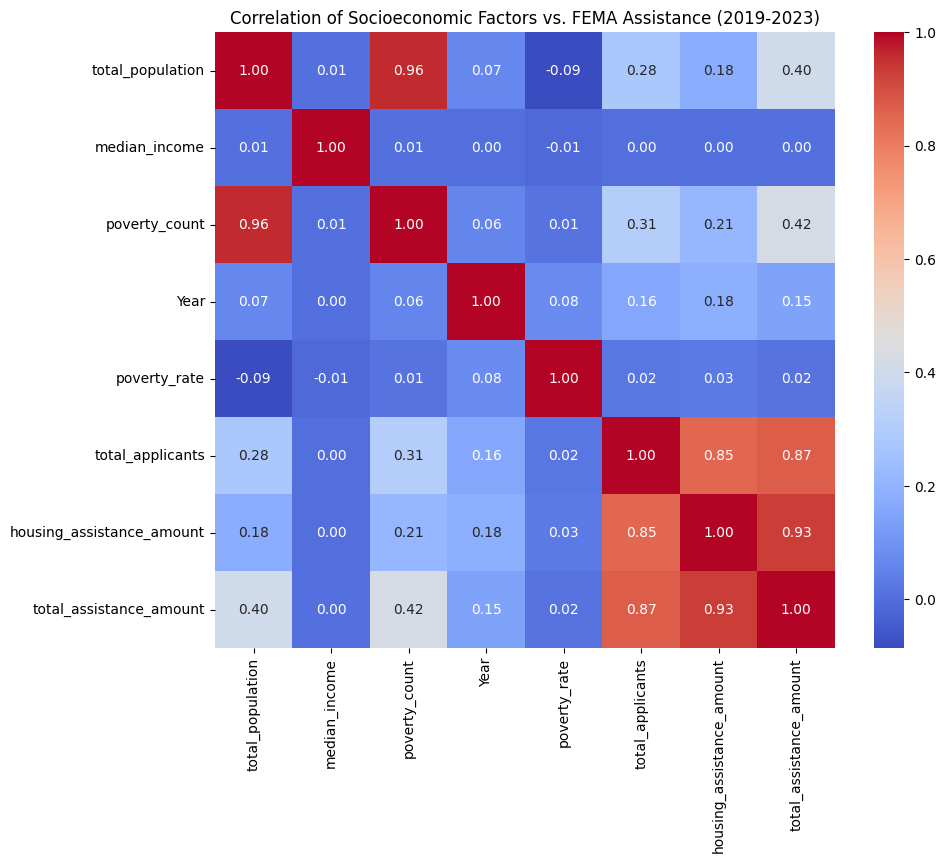

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load your masterpiece
df = pd.read_csv('data/master_disaster_data.csv')

# 1. Correlation Heatmap
plt.figure(figsize=(10, 8))
# We only want numeric columns for a heatmap
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation of Socioeconomic Factors vs. FEMA Assistance (2019-2023)')
plt.show()

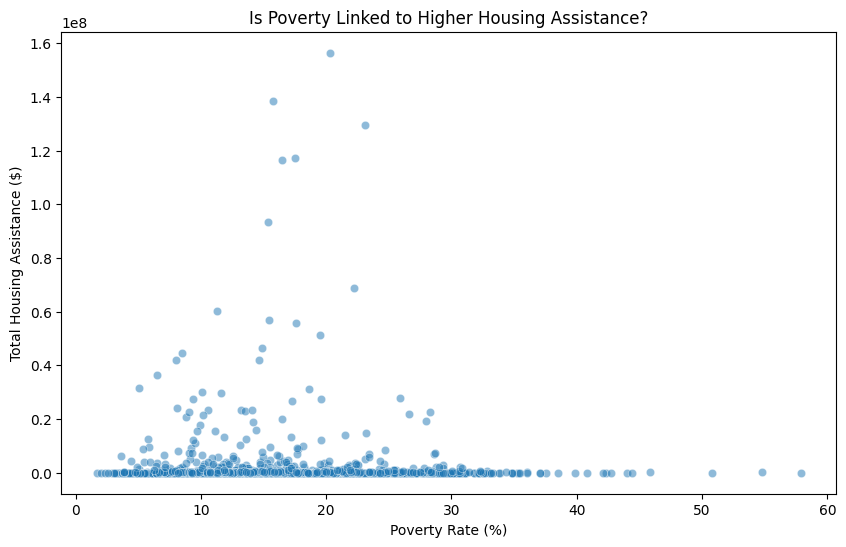

In [ ]:
# 2. Scatter Plot: Poverty vs. Assistance
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='poverty_rate', y='housing_assistance_amount', alpha=0.5)
plt.title('Is Poverty Linked to Higher Housing Assistance?')
plt.xlabel('Poverty Rate (%)')
plt.ylabel('Total Housing Assistance ($)')
plt.show()

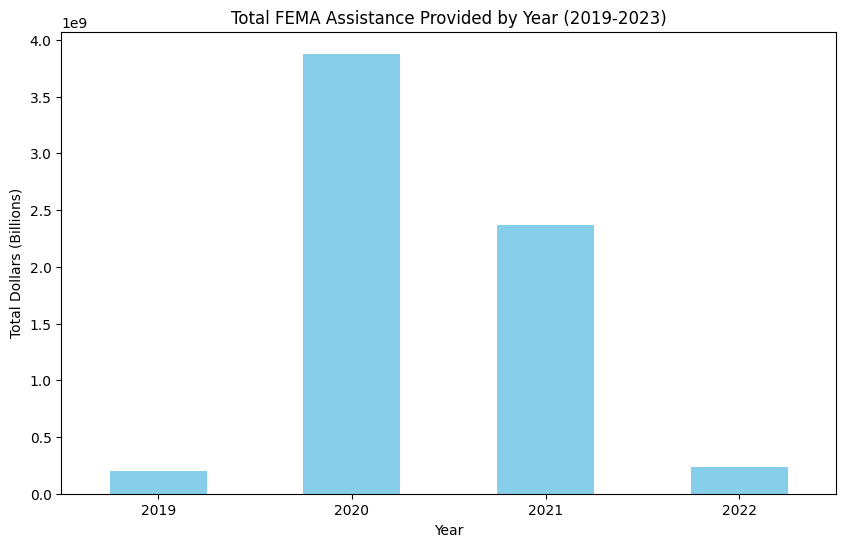

In [ ]:
# 3. Bar Chart: Total Aid per Year
plt.figure(figsize=(10, 6))
df.groupby('Year')['total_assistance_amount'].sum().plot(kind='bar', color='skyblue')
plt.title('Total FEMA Assistance Provided by Year (2019-2023)')
plt.ylabel('Total Dollars (Billions)')
plt.xticks(rotation=0)
plt.show()

In [ ]:
# 4. FEATURE ENGINEERING: Normalizing the Data
# Assistance per Capita: How much aid did the average resident get?
df['assistance_per_capita'] = df['total_assistance_amount'] / df['total_population']
# Assistance per Applicant: How much did the average victim receive?
df['assistance_per_applicant'] = df['total_assistance_amount'] / df['total_applicants']

/tmp/ipykernel_1356/1759582338.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_total.values, y=state_total.index, palette='viridis')


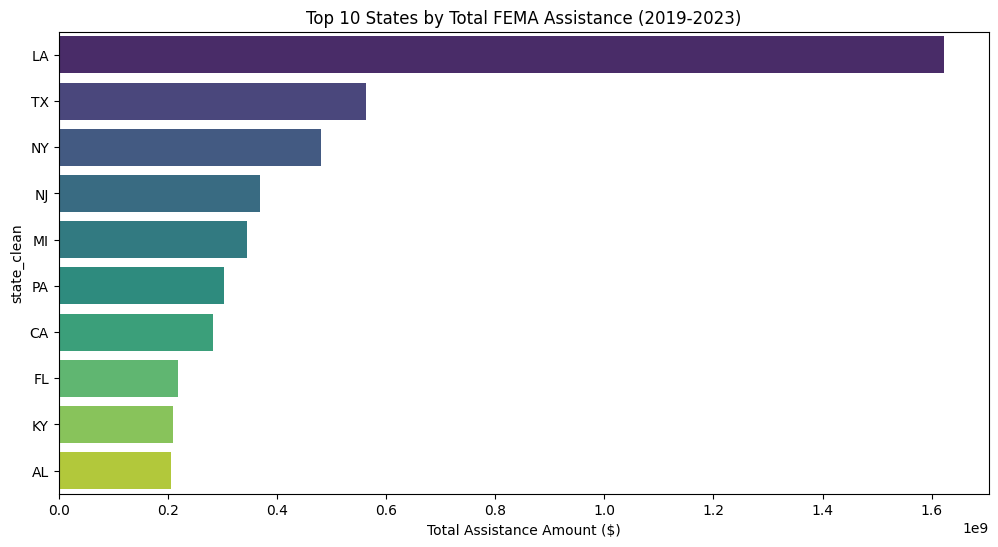

In [ ]:
# 5. GEOGRAPHIC ANALYSIS: Top 10 States by Total Aid
plt.figure(figsize=(12, 6))
state_total = df.groupby('state_clean')['total_assistance_amount'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=state_total.values, y=state_total.index, palette='viridis')
plt.title('Top 10 States by Total FEMA Assistance (2019-2023)')
plt.xlabel('Total Assistance Amount ($)')
plt.show()

/tmp/ipykernel_1356/1874274134.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='poverty_tier', y='assistance_per_applicant', palette='Set2')


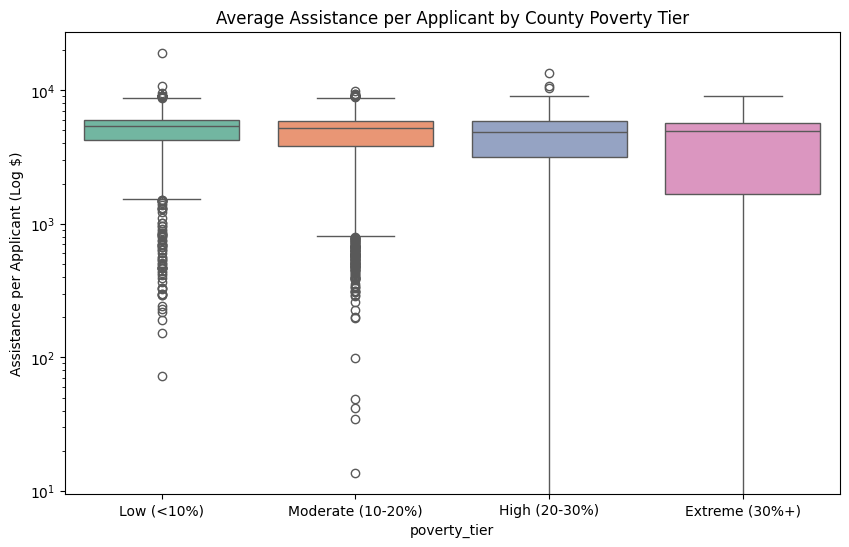

In [ ]:
# 6. VULNERABILITY ANALYSIS: Poverty Tiers
# We create "bins" for poverty to see if there is a 'tipping point'
df['poverty_tier'] = pd.cut(df['poverty_rate'],
                            bins=[0, 10, 20, 30, 100],
                            labels=['Low (<10%)', 'Moderate (10-20%)', 'High (20-30%)', 'Extreme (30%+)'])

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='poverty_tier', y='assistance_per_applicant', palette='Set2')
plt.yscale('log') # Log scale helps see the distribution across tiers
plt.title('Average Assistance per Applicant by County Poverty Tier')
plt.ylabel('Assistance per Applicant (Log $)')
plt.show()

/tmp/ipykernel_1356/120462994.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df, x='Year', y='total_applicants', estimator='sum', ci=None, marker='o')


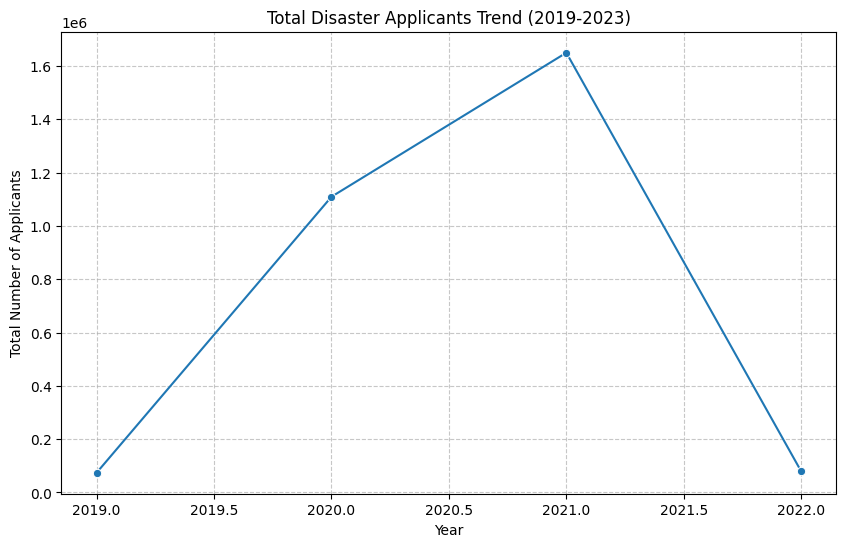

In [ ]:
# 7. TEMPORAL ANALYSIS: Applicant Volume by Year
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Year', y='total_applicants', estimator='sum', ci=None, marker='o')
plt.title('Total Disaster Applicants Trend (2019-2023)')
plt.ylabel('Total Number of Applicants')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# 8. SUMMARY TABLE: The "Top 10 Outlier" Counties
# These are counties that received the most aid relative to their population
top_outliers = df.nlargest(10, 'assistance_per_capita')[['Year', 'state_clean', 'county_clean', 'poverty_rate', 'assistance_per_capita']]
print("Top 10 Counties by Assistance per Capita")
print(top_outliers)

Top 10 Counties by Assistance per Capita
      Year state_clean         county_clean  poverty_rate  \
543   2020          LA              CAMERON      9.493035   
3565  2022          KY                KNOTT     26.592914   
3562  2022          KY            BREATHITT     27.989691   
3334  2021          LA  ST JOHN THE BAPTIST     14.663732   
3339  2021          LA           TERREBONNE     17.521344   
3318  2021          LA            LAFOURCHE     15.373118   
3568  2022          KY              LETCHER     28.301536   
3332  2021          LA            ST HELENA     24.712802   
3333  2021          LA             ST JAMES     11.848946   
3331  2021          LA           ST CHARLES     10.085669   

      assistance_per_capita  
543             2151.114413  
3565            1713.663652  
3562            1692.621445  
3334            1479.079236  
3339            1473.570758  
3318            1306.620145  
3568            1223.530572  
3332            1028.817809  
3333             

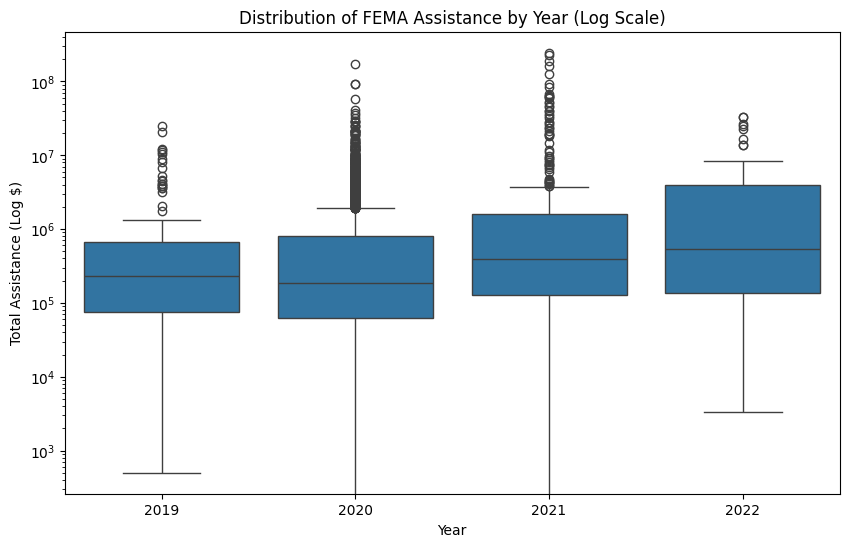

In [ ]:
# 9. Distribution Analysis: Boxplot by Year (Log Scale)
# Essential for showing the massive range (variance) in disaster impacts
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Year', y='total_assistance_amount')
plt.yscale('log')
plt.title('Distribution of FEMA Assistance by Year (Log Scale)')
plt.ylabel('Total Assistance (Log $)')
plt.show()

/tmp/ipykernel_1356/2261172931.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  poverty_vulnerability = df.groupby('poverty_tier')['total_assistance_amount'].mean().reset_index()
/tmp/ipykernel_1356/2261172931.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=poverty_vulnerability, x='poverty_tier', y='total_assistance_amount', palette='magma')


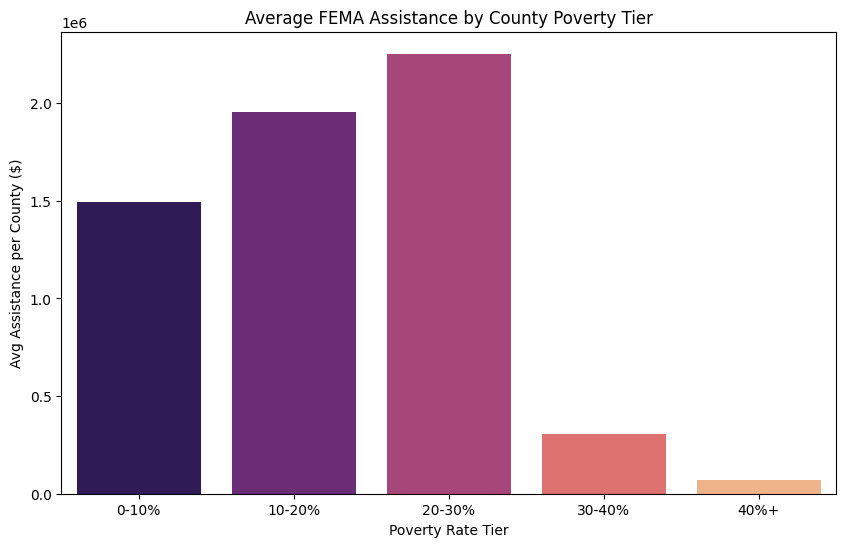

In [ ]:
# 10. Vulnerability Tiers: Assistance vs. Poverty Rate
# We create "bins" to see if there is a tipping point in aid
df['poverty_tier'] = pd.cut(df['poverty_rate'], bins=[0, 10, 20, 30, 40, 100],
                            labels=['0-10%', '10-20%', '20-30%', '30-40%', '40%+'])
poverty_vulnerability = df.groupby('poverty_tier')['total_assistance_amount'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=poverty_vulnerability, x='poverty_tier', y='total_assistance_amount', palette='magma')
plt.title('Average FEMA Assistance by County Poverty Tier')
plt.xlabel('Poverty Rate Tier')
plt.ylabel('Avg Assistance per County ($)')
plt.show()